In [60]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

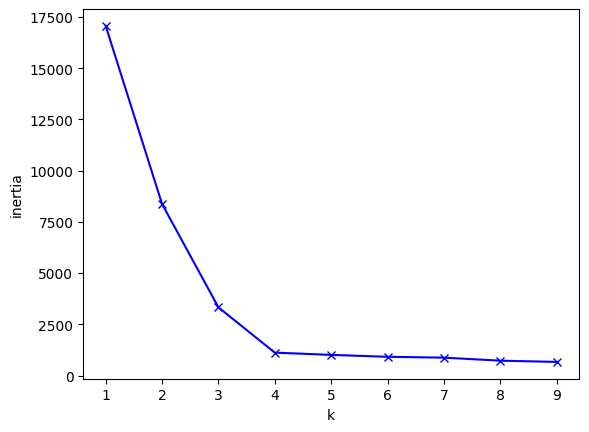

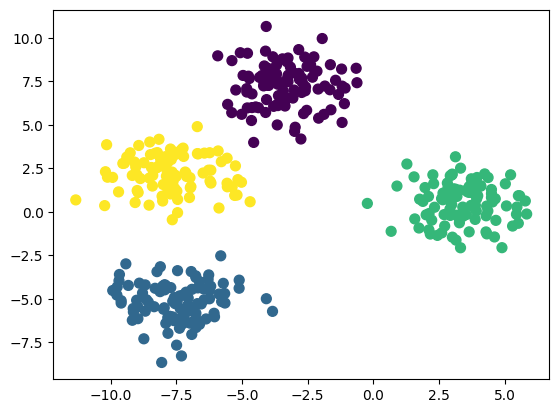

In [69]:
X, y = make_blobs(n_samples=400, centers=4, cluster_std=1.2, random_state=43)

inertia = []
K = range(1,10)

for k in K:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X)
  inertia.append(kmeans.inertia_)

plt.plot(K, inertia, 'bx-')
plt.xlabel('k')
plt.ylabel('inertia')
plt.show()

optimal = 4
kmeans = KMeans(n_clusters=optimal, random_state=42)
kmeans.fit(X)
labels = kmeans.labels_
centers = kmeans.cluster_centers_

plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')

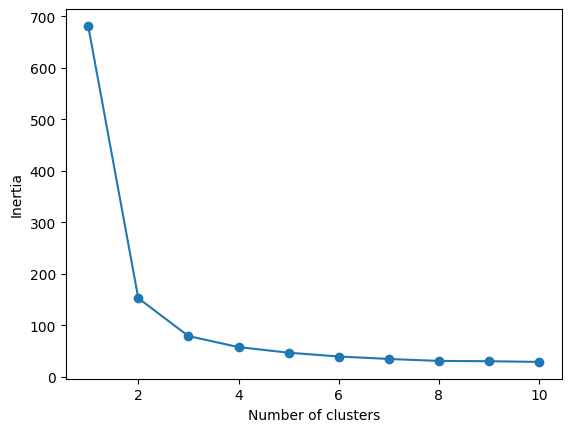

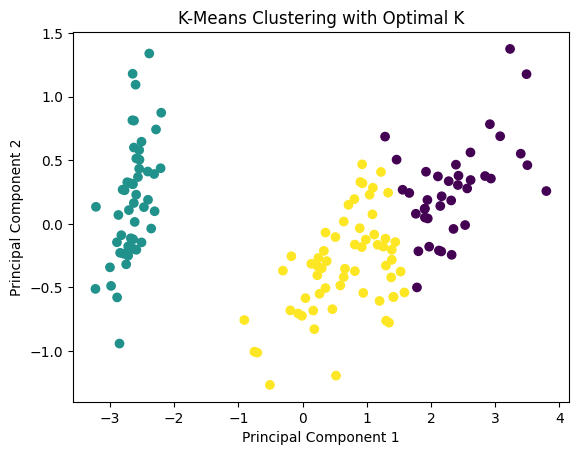

In [70]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
import pandas as pd

iris = load_iris()
X = iris.data
y_true = iris.target

inertia = []

for i in range(1,11):
  kmeans = KMeans(n_clusters=i, random_state=42)
  kmeans.fit(X)
  inertia.append(kmeans.inertia_)

plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()


optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels = kmeans.fit_predict(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering with Optimal K')
plt.show()

In [71]:
conf_mat = confusion_matrix(y_true, labels)
print("Confusion Matrix:")
print(conf_mat)
rand_score = adjusted_rand_score(y_true, labels)
ami_score = adjusted_mutual_info_score(y_true, labels)
print()

print("Rand Index:", rand_score)
print("AMI:", ami_score)

Confusion Matrix:
[[ 0 50  0]
 [ 3  0 47]
 [36  0 14]]

Rand Index: 0.7163421126838476
AMI: 0.7386548254402864


In [72]:
import numpy as np
from sklearn.preprocessing import RobustScaler, StandardScaler


X = np.array([[10],[11],[12],[13],[1000]])  # outlier 1000

print("StandardScaler:", StandardScaler().fit_transform(X).ravel())
print("RobustScaler:  ", RobustScaler().fit_transform(X).ravel())

StandardScaler: [-0.50379202 -0.50126294 -0.49873386 -0.49620479  1.9999936 ]
RobustScaler:   [ -1.   -0.5   0.    0.5 494. ]


kmeans_Mall_Customers

Text(0, 0.5, 'Inertia')

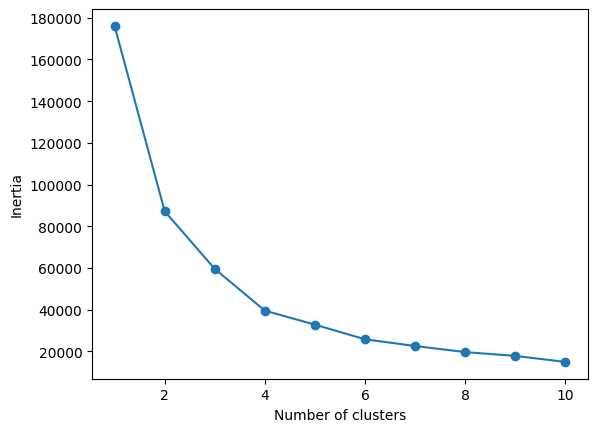

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = pd.read_csv('/content/Mall_Customers.csv')
X = data[['Age', 'Annual Income (k$)']]
inertia = []
K_values = range(1, 11)

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K_values, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')


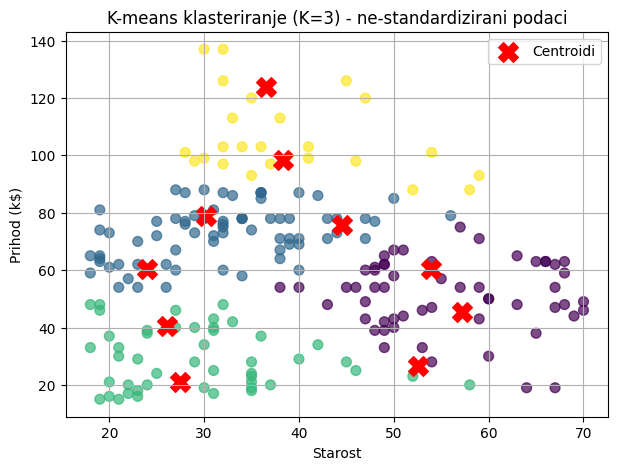

In [74]:

optimal_mall = 4
kmeans_mall = KMeans(n_clusters=optimal_mall, random_state=42)
labels_mall = kmeans_mall.fit_predict(X)
data['Cluster'] = labels_mall

plt.figure(figsize=(7, 5))
plt.scatter(X['Age'], X['Annual Income (k$)'], c=labels_mall, cmap='viridis', s=50, alpha=0.7)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Centroidi')
plt.title(f"K-means klasteriranje (K={optimal_k}) - ne-standardizirani podaci")
plt.xlabel("Starost")
plt.ylabel("Prihod (k$)")
plt.legend();plt.grid(True);plt.show()

Text(0, 0.5, 'Inertia')

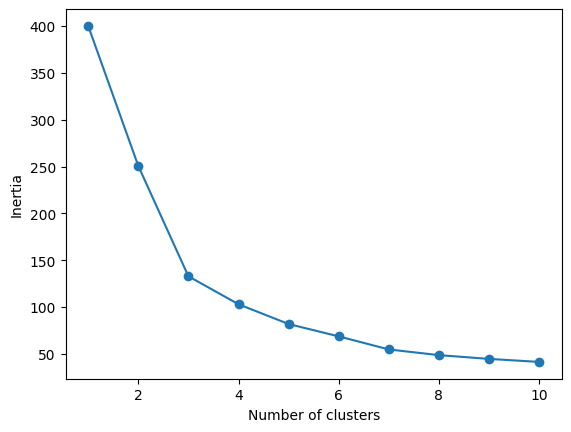

In [75]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []

K_values = range(1, 11)
for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_values, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

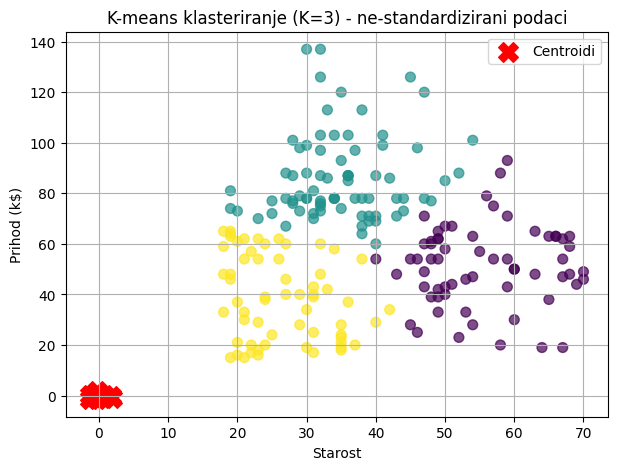

In [76]:
optimal_k = 3
kmeans_scaled = KMeans(n_clusters=optimal_k, random_state=42)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X['Age'], X['Annual Income (k$)'], c=labels_scaled, cmap='viridis', s=50, alpha=0.7)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Centroidi')
plt.title(f"K-means klasteriranje (K={optimal_k}) - ne-standardizirani podaci")
plt.xlabel("Starost")
plt.ylabel("Prihod (k$)")
plt.legend();plt.grid(True);plt.show()